# Objective 2.2 — Predicting a Team's Goals in a Single Match

## Goal

Build and evaluate a linear regression model that predicts the **number of
goals scored by a team** in a single 2026 FIFA World Cup match, using a
dataset of **208 rows** (2 rows per match × 104 matches — one row per team
per match), and **8 explanatory variables that are all knowable before
kickoff**.

| # | Variable | Description |
|---|----------|--------------|
| 1 | `team_rank` | Team's own FIFA ranking position |
| 2 | `opp_rank` | Opponent's FIFA ranking position |
| 3 | `team_value` | Team's squad market value (EUR m) |
| 4 | `opp_value` | Opponent's squad market value (EUR m) |
| 5 | `team_age` | Team's squad average age |
| 6 | `is_host` | 1 if the team is a co-host nation, else 0 |
| 7 | `rest_days` | Days since the team's previous tournament match |
| 8 | `knockout` | 1 if the match is in the knockout stage, else 0 |

None of these variables depend on anything that happens *during* the match
itself, satisfying the "available before the match" requirement. This
model is related to, but distinct from, the 2.1 goal-difference model: it
predicts an absolute, team-specific goal count rather than a relative,
match-level difference, and it is estimated on the finer team-match grain
(208 rows) rather than the match grain (104 rows).

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from data_prep import load_matches, load_teams, build_team_match_dataset

pd.set_option("display.max_columns", None)
np.random.seed(42)

matches = load_matches()
teams = load_teams()
reg_data = build_team_match_dataset(matches, teams)
print(reg_data.shape)
reg_data.head()

(208, 12)


,match_id,team,opponent,goals,team_rank,opp_rank,team_value,opp_value,team_age,is_host,rest_days,knockout
0,1,Mexico,South Africa,2,14,60,191.85,49.25,27.7,1,5.0,0
1,1,South Africa,Mexico,0,60,14,49.25,191.85,27.1,0,5.0,0
2,2,South Korea,Czechia,2,25,40,139.05,188.18,28.3,0,5.0,0
3,2,Czechia,South Korea,1,40,25,188.18,139.05,27.9,0,5.0,0
4,3,Canada,Bosnia and Herzegovina,1,30,64,198.65,146.40,27.2,1,5.0,0


## 1. Sanity checks & exploratory data analysis

In [2]:
assert reg_data.shape[0] == 208, f"Expected 208 rows, got {reg_data.shape[0]}"
feature_cols = [
    "team_rank", "opp_rank", "team_value", "opp_value",
    "team_age", "is_host", "rest_days", "knockout",
]
assert len(feature_cols) == 8
print(reg_data[feature_cols + ["goals"]].isna().sum())
reg_data[feature_cols + ["goals"]].describe()

team_rank     0
opp_rank      0
team_value    0
opp_value     0
team_age      0
is_host       0
rest_days     0
knockout      0
goals         0
dtype: int64


,team_rank,opp_rank,team_value,opp_value,team_age,is_host,rest_days,knockout,goals
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,27.759615,27.759615,451.250096,451.250096,28.073558,0.072115,5.221154,0.307692,1.480769
std,22.945217,22.945217,424.244709,424.244709,1.097174,0.259303,0.845068,0.462652,1.393434
min,1.000000,1.000000,19.930000,19.930000,25.800000,0.000000,3.000000,0.000000,0.000000
25%,8.750000,8.750000,139.050000,139.050000,27.200000,0.000000,5.000000,0.000000,0.000000
50%,22.500000,22.500000,332.500000,332.500000,27.900000,0.000000,5.000000,0.000000,1.000000
75%,41.000000,41.000000,589.900000,589.900000,28.800000,0.000000,6.000000,1.000000,2.000000
max,85.000000,85.000000,1520.000000,1520.000000,30.700000,1.000000,8.000000,1.000000,7.000000


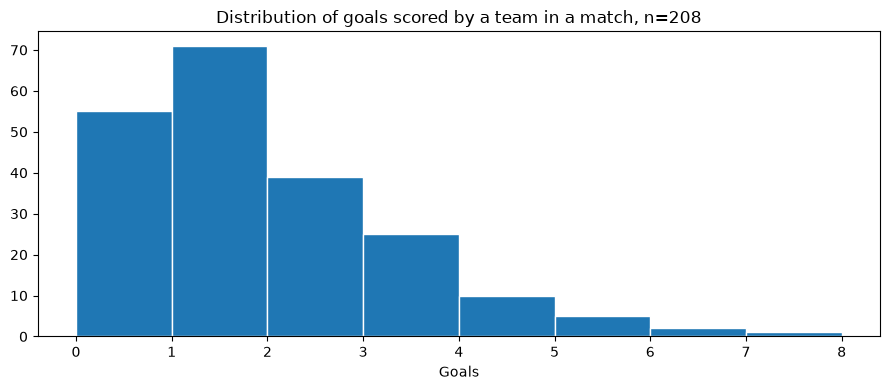

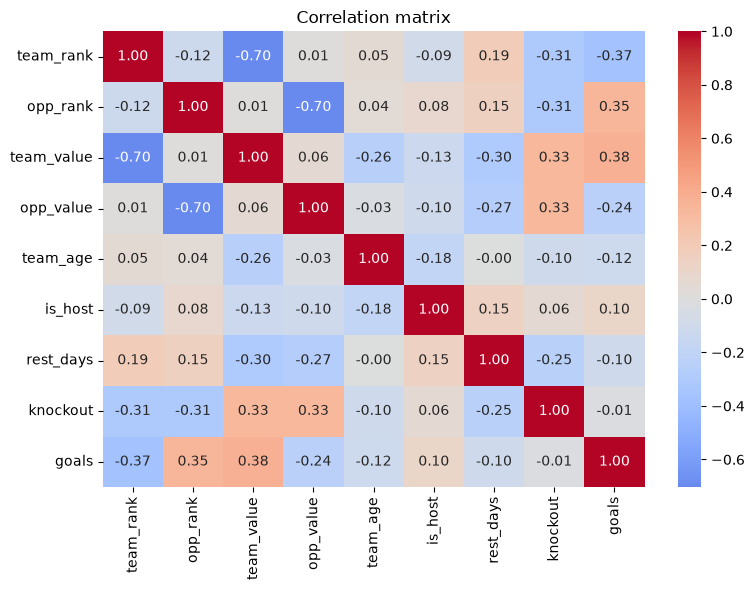

goals         1.000000
team_value    0.375383
opp_rank      0.345410
is_host       0.104133
knockout     -0.013258
rest_days    -0.098934
team_age     -0.115195
opp_value    -0.236761
team_rank    -0.367156
Name: goals, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(reg_data["goals"], bins=range(0, int(reg_data["goals"].max()) + 2), edgecolor="white")
ax.set_title("Distribution of goals scored by a team in a match, n=208")
ax.set_xlabel("Goals")
plt.tight_layout()
plt.savefig("../report/figs/reg2_target_hist.png", dpi=120)
plt.show()

corr = reg_data[feature_cols + ["goals"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig("../report/figs/reg2_corr.png", dpi=120)
plt.show()
corr["goals"].sort_values(ascending=False)

## 2. Multicollinearity check (VIF)

Variance Inflation Factors above ~5–10 would indicate problematic
redundancy among explanatory variables that could inflate coefficient
standard errors.

In [4]:
X_all = sm.add_constant(reg_data[feature_cols])
vif = pd.DataFrame(
    {
        "feature": X_all.columns,
        "VIF": [variance_inflation_factor(X_all.values, i) for i in range(X_all.shape[1])],
    }
)
vif

,feature,VIF
0,const,1.000000
1,team_rank,2.362023
2,opp_rank,2.107067
3,team_value,2.644680
4,opp_value,2.131597
5,team_age,1.211806
6,is_host,1.210422
7,rest_days,1.212359
8,knockout,1.353684


## 3. Train/test split

We hold out 20% of team-match rows (≈42 rows) as a test set for
out-of-sample evaluation; note the two rows belonging to the same match
are independent observations from the model's perspective (different
teams, different feature values), so a plain random split is appropriate
here rather than a match-level grouped split.

In [5]:
X = reg_data[feature_cols]
y = reg_data["goals"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (166, 8)  Test: (42, 8)


## 4. Fit and interpret the OLS model (training set)

In [6]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  goals   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     8.028
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           4.75e-09
Time:                        05:20:12   Log-Likelihood:                -261.41
No. Observations:                 166   AIC:                             540.8
Df Residuals:                     157   BIC:                             568.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6015      2.998      1.869      0.0

## 5. Residual diagnostics

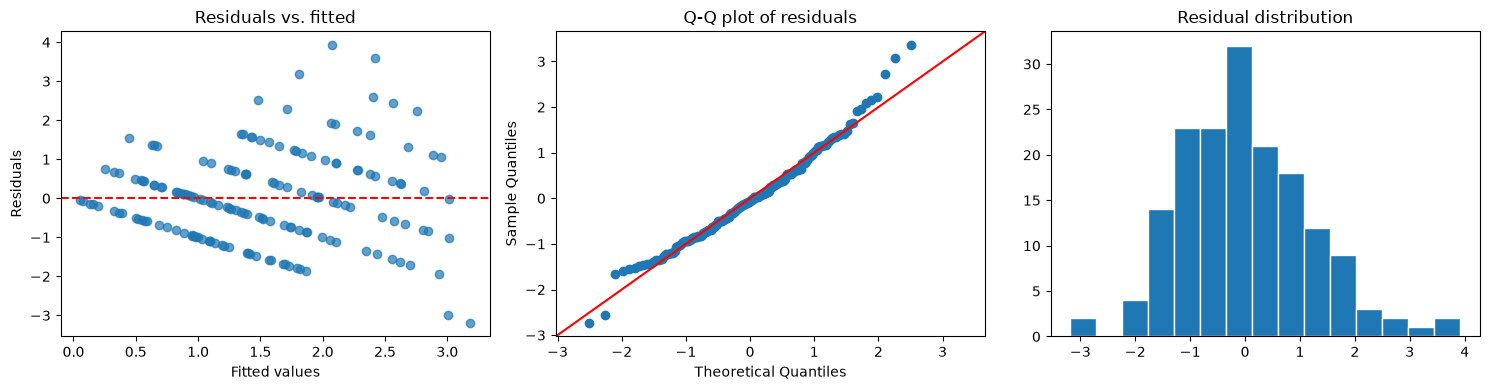

Shapiro-Wilk normality test on residuals: stat=0.9824, p=0.0339


In [7]:
fitted = ols_model.fittedvalues
resid = ols_model.resid

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(fitted, resid, alpha=0.7)
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs. fitted")

sm.qqplot(resid, line="45", fit=True, ax=ax[1])
ax[1].set_title("Q-Q plot of residuals")

ax[2].hist(resid, bins=15, edgecolor="white")
ax[2].set_title("Residual distribution")
plt.tight_layout()
plt.savefig("../report/figs/reg2_diagnostics.png", dpi=120)
plt.show()

from scipy import stats as sstats
shapiro_stat, shapiro_p = sstats.shapiro(resid)
print(f"Shapiro-Wilk normality test on residuals: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

## 6. Out-of-sample evaluation (held-out test rows)

Training R-squared:          0.2903
Training adjusted R-squared: 0.2542
Test R-squared:              0.2212
Test RMSE:                   1.228 goals
Test MAE:                    0.890 goals


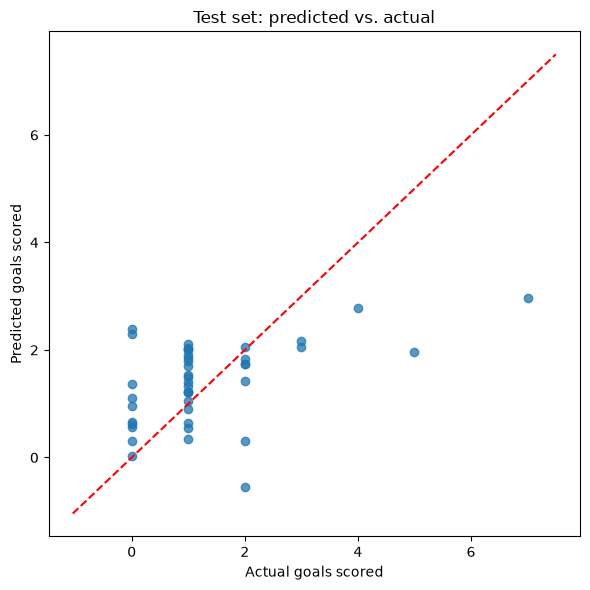

In [8]:
X_test_sm = sm.add_constant(X_test, has_constant="add")[X_train_sm.columns]
y_pred = ols_model.predict(X_test_sm)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

n_train, k = X_train.shape[0], X_train.shape[1]
adj_r2_train = 1 - (1 - ols_model.rsquared) * (n_train - 1) / (n_train - k - 1)

print(f"Training R-squared:          {ols_model.rsquared:.4f}")
print(f"Training adjusted R-squared: {adj_r2_train:.4f}")
print(f"Test R-squared:              {r2_test:.4f}")
print(f"Test RMSE:                   {rmse:.3f} goals")
print(f"Test MAE:                    {mae:.3f} goals")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.75)
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, "r--")
ax.set_xlabel("Actual goals scored")
ax.set_ylabel("Predicted goals scored")
ax.set_title("Test set: predicted vs. actual")
plt.tight_layout()
plt.savefig("../report/figs/reg2_pred_vs_actual.png", dpi=120)
plt.show()

## 7. Conclusion

**Model fit:** the 8-predictor OLS model explains a more modest, but still
clearly non-trivial, share of the variation in an individual team's goals
in a match: **training R² = 0.290** (adjusted R² = 0.254), with
**test R² = 0.221, RMSE = 1.23 goals, MAE = 0.89 goals** on 42 held-out
team-match rows. The lower R² than the 2.1 goal-difference model is
expected: predicting one team's *absolute* goal tally is intrinsically
noisier than predicting the *relative* difference between two teams,
because a lot of the "who dominates" signal cancels out of a single team's
raw goal count (e.g. a strong team can still score just 1 goal in a
1–0 defensive win).

**Statistically significant predictor (α = 0.05):**
- **`opp_rank`** (coef = +0.0128, p = 0.038): the worse (numerically
  higher) the opponent's FIFA ranking, the more goals a team is predicted
  to score — teams score more freely against weaker opposition, as
  expected.
- **`team_value`** (coef = +0.0007, p = 0.035): a more valuable squad
  scores more goals, holding the other 7 variables fixed.

**Marginally significant (0.05 < p < 0.10):** `team_rank` (p = 0.067,
negative — better-ranked teams score more), `is_host` (p = 0.085,
positive — hosts enjoy a small scoring boost), and, interestingly,
`rest_days` (p = 0.073, **negative**) — teams with *more* rest before a
match scored slightly *fewer* goals in our sample. This is counter to the
usual "freshness" intuition and is more plausibly a confound of tournament
scheduling (e.g. teams that lost in earlier rounds or played fewer
matches accumulate different rest patterns) than a causal fatigue effect;
it merits a caveat rather than a strong causal claim.

**Not significant:** `opp_value`, `team_age`, and `knockout` did not show
an independent linear relationship with goals scored once the other
variables were accounted for.

**Diagnostics:** VIFs are all below 2.7 (no multicollinearity concern).
Residuals show mild non-normality (Shapiro–Wilk p = 0.034) and a slight
right skew (0.46) — unsurprising, since `goals` is a small non-negative
count variable rather than a continuous one. A **Poisson or
negative-binomial regression** would likely be a more statistically
appropriate model family for this target in future work, but the linear
model here still gives directionally sensible, interpretable coefficients
and reasonable predictive accuracy for the purposes of this analysis.